# Review Sentiment Classification

**Goal:** Predict review `Sentiment` (Positive / Neutral / Negative) from the review `Summary`. Starting with a Logistic Regression baseline, then implementing and evaluating additional algorithms one by one, comparing all of them on identical metrics to pick the best model.

**Primary evaluation metric:** F1 (weighted) — balances precision and recall across all three classes. Accuracy and Precision/Recall are also tracked for completeness.

---

## 1. Import Required Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

## 2. Load Data

In [21]:
df=pd.read_csv("Clean_file.csv")

In [22]:
df.head()

,Unnamed: 0,Score,Summary,Text,Sentiment
0,0,5,good quality dog food,bought several vitality canned dog food produc...,Positive
1,1,1,advertised,product arrived labeled jumbo salted peanut .....,Negative
2,2,4,delight say,confection around century . light pillowy citr...,Positive
3,3,2,cough medicine,looking secret ingredient robitussin believe f...,Negative
4,4,5,great taffy,great taffy great price . wide assortment yumm...,Positive


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568401 entries, 0 to 568400
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  568401 non-null  int64
 1   Score       568401 non-null  int64
 2   Summary     567264 non-null  str  
 3   Text        568401 non-null  str  
 4   Sentiment   568401 non-null  str  
dtypes: int64(2), str(3)
memory usage: 182.3 MB


In [24]:
df.isnull().sum()

Unnamed: 0       0
Score            0
Summary       1137
Text             0
Sentiment        0
dtype: int64

In [25]:
#droping rows with missing Summary/Sentiment
df=df.dropna(subset=["Summary","Sentiment"])

## 3. Define Input features and Target variable

In [26]:
X = df["Summary"]          # input feature
y = df["Sentiment"]         # target variable

## 4. Balance the Classes (Undersampling)
Majority classes are downsampled to match the minority class size so no model is biased toward `Positive`.

In [27]:
class_counts = y.value_counts()
min_size = class_counts.min()

balanced = pd.concat([
    resample(df[df["Sentiment"] == cls], replace=False, n_samples=min_size, random_state=42)
    for cls in class_counts.index
]).sample(frac=1, random_state=42).reset_index(drop=True)

X = balanced["Summary"]
y = balanced["Sentiment"]
y.value_counts()

Sentiment
Positive    42380
Negative    42380
Neutral     42380
Name: count, dtype: int64

## 5. Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 6. Preprocessing Pipeline
This vectorizer is reused for every model below so that all comparisons are fair — same features, same vocabulary.

In [29]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2)

## 7. Results tracker

In [30]:
results = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
results

,Model,Accuracy,Precision,Recall,F1


## 8. Baseline Model — Logistic Regression
Used as the baseline because it's simple, fast, interpretable, and requires no tuning. It establishes the performance floor that every later model must beat to justify its added complexity.

In [31]:
baseline_model = Pipeline(steps=[
    ("tfidf", tfidf),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Negative','Neutral','Positive']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",8000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [32]:
y_pred = baseline_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Logistic Regression")
print(classification_report(y_test,y_pred))

Logistic Regression
              precision    recall  f1-score   support

    Negative       0.68      0.69      0.69      8476
     Neutral       0.65      0.59      0.62      8476
    Positive       0.72      0.76      0.74      8476

    accuracy                           0.68     25428
   macro avg       0.68      0.68      0.68     25428
weighted avg       0.68      0.68      0.68     25428



In [33]:
results.loc[len(results)] = ["Logistic Regression", acc, prec, rec, f1]
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.684128,0.682422,0.684128,0.682587


## 9. Support Vector Machine (SVM)
`LinearSVC` scales well to TF-IDF's high-dimensional sparse features and typically performs strongly on text classification.

In [34]:
svm_model = Pipeline(steps=[
    ("tfidf", tfidf),
    ("classifier", LinearSVC(random_state=42, max_iter=5000)),
])

svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Negative','Neutral','Positive']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",8000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [36]:
y_pred = svm_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("SVM")
print(classification_report(y_test,y_pred))

SVM
              precision    recall  f1-score   support

    Negative       0.67      0.69      0.68      8476
     Neutral       0.66      0.57      0.61      8476
    Positive       0.71      0.77      0.74      8476

    accuracy                           0.68     25428
   macro avg       0.68      0.68      0.68     25428
weighted avg       0.68      0.68      0.68     25428



In [37]:
results.loc[len(results)] = ["SVM", acc, prec, rec, f1]
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.684128,0.682422,0.684128,0.682587
1,SVM,0.678111,0.676471,0.678111,0.675843


## 10. Naive Bayes
A strong, cheap-to-train baseline for text — assumes word occurrences are conditionally independent given the class.

In [38]:
nb_model = Pipeline(steps=[
    ("tfidf", tfidf),
    ("classifier", MultinomialNB()),
])

nb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U8](3,)","['Negative','Neutral','Positive']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",8000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [39]:
y_pred = nb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Naive Bayes")
print(classification_report(y_test,y_pred))

Naive Bayes
              precision    recall  f1-score   support

    Negative       0.68      0.67      0.67      8476
     Neutral       0.62      0.58      0.60      8476
    Positive       0.70      0.76      0.73      8476

    accuracy                           0.67     25428
   macro avg       0.67      0.67      0.67     25428
weighted avg       0.67      0.67      0.67     25428



In [40]:
results.loc[len(results)] = ["Naive Bayes", acc, prec, rec, f1]
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.684128,0.682422,0.684128,0.682587
1,SVM,0.678111,0.676471,0.678111,0.675843
2,Naive Bayes,0.668279,0.666367,0.668279,0.666626


## 11. Decision Tree
Captures non-linear word-combination effects that linear models can't represent.

In [41]:
dt_model = Pipeline(steps=[
    ("tfidf", tfidf),
    ("classifier", DecisionTreeClassifier(max_depth=40, min_samples_leaf=3, random_state=42)),
])

dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Negative','Neutral','Positive']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",8000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [42]:
y_pred = dt_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Decision Tree")
print(classification_report(y_test,y_pred))

Decision Tree
              precision    recall  f1-score   support

    Negative       0.46      0.93      0.62      8476
     Neutral       0.70      0.25      0.37      8476
    Positive       0.79      0.51      0.62      8476

    accuracy                           0.56     25428
   macro avg       0.65      0.56      0.54     25428
weighted avg       0.65      0.56      0.54     25428



In [43]:
results.loc[len(results)] = ["Decision Tree", acc, prec, rec, f1]
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.684128,0.682422,0.684128,0.682587
1,SVM,0.678111,0.676471,0.678111,0.675843
2,Naive Bayes,0.668279,0.666367,0.668279,0.666626
3,Decision Tree,0.561350,0.652293,0.561350,0.535257


## 12. Random Forest
An ensemble of decision trees that usually generalizes better than a single tree by averaging out overfitting.

In [44]:
rf_model = Pipeline(steps=[
    ("tfidf", tfidf),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Negative','Neutral','Positive']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",8000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [45]:
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Random Forest")
print(classification_report(y_test,y_pred))

Random Forest
              precision    recall  f1-score   support

    Negative       0.70      0.75      0.72      8476
     Neutral       0.69      0.64      0.66      8476
    Positive       0.75      0.76      0.75      8476

    accuracy                           0.71     25428
   macro avg       0.71      0.71      0.71     25428
weighted avg       0.71      0.71      0.71     25428



In [46]:
results.loc[len(results)] = ["Random Forest", acc, prec, rec, f1]
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.684128,0.682422,0.684128,0.682587
1,SVM,0.678111,0.676471,0.678111,0.675843
2,Naive Bayes,0.668279,0.666367,0.668279,0.666626
3,Decision Tree,0.561350,0.652293,0.561350,0.535257
4,Random Forest,0.713780,0.713538,0.713780,0.713001


## 13. Gradient Boosting
Builds trees sequentially, each correcting the errors of the previous one.

In [47]:
gb_model = Pipeline(steps=[
    ("tfidf", tfidf),
    ("classifier", GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
])

gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Negative','Neutral','Positive']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",8000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [48]:
y_pred = gb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Gradient Boosting")
print(classification_report(y_test,y_pred))

Gradient Boosting
              precision    recall  f1-score   support

    Negative       0.49      0.84      0.62      8476
     Neutral       0.61      0.38      0.47      8476
    Positive       0.77      0.51      0.61      8476

    accuracy                           0.57     25428
   macro avg       0.62      0.57      0.57     25428
weighted avg       0.62      0.57      0.57     25428



In [49]:
results.loc[len(results)] = ["Gradient Boosting", acc, prec, rec, f1]
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.684128,0.682422,0.684128,0.682587
1,SVM,0.678111,0.676471,0.678111,0.675843
2,Naive Bayes,0.668279,0.666367,0.668279,0.666626
3,Decision Tree,0.561350,0.652293,0.561350,0.535257
4,Random Forest,0.713780,0.713538,0.713780,0.713001
5,Gradient Boosting,0.574996,0.621257,0.574996,0.565196


## 14. XGBoost
Optimized, regularized gradient boosting — usually the strongest performer among tree-based models.

In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_model = Pipeline(steps=[
    ("tfidf", tfidf),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42
    )),
])

xgb_model.fit(X_train, y_train_enc)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",8000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [52]:
y_pred = xgb_model.predict(X_test)

acc = accuracy_score(y_test_enc, y_pred)
prec = precision_score(y_test_enc, y_pred, average="weighted")
rec = recall_score(y_test_enc, y_pred, average="weighted")
f1 = f1_score(y_test_enc, y_pred, average="weighted")

print("XGBoost")
print(classification_report(y_test_enc,y_pred))

XGBoost
              precision    recall  f1-score   support

           0       0.55      0.81      0.66      8476
           1       0.66      0.47      0.55      8476
           2       0.77      0.61      0.68      8476

    accuracy                           0.63     25428
   macro avg       0.66      0.63      0.63     25428
weighted avg       0.66      0.63      0.63     25428



In [53]:
results.loc[len(results)] = ["XGBoost", acc, prec, rec, f1]
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.684128,0.682422,0.684128,0.682587
1,SVM,0.678111,0.676471,0.678111,0.675843
2,Naive Bayes,0.668279,0.666367,0.668279,0.666626
3,Decision Tree,0.561350,0.652293,0.561350,0.535257
4,Random Forest,0.713780,0.713538,0.713780,0.713001
5,Gradient Boosting,0.574996,0.621257,0.574996,0.565196
6,XGBoost,0.632728,0.658001,0.632728,0.628680


## 15. Overfitting / Underfitting Check

In [54]:
models = {
    "Logistic Regression": (baseline_model, y_train, y_test),
    "SVM": (svm_model, y_train, y_test),
    "Naive Bayes": (nb_model, y_train, y_test),
    "Decision Tree": (dt_model, y_train, y_test),
    "Random Forest": (rf_model, y_train, y_test),
    "Gradient Boosting": (gb_model, y_train, y_test),
    "XGBoost": (xgb_model, y_train_enc, y_test_enc),
}

for name, (model, ytr, yte) in models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_f1 = f1_score(ytr, train_pred, average="weighted")
    test_f1 = f1_score(yte, test_pred, average="weighted")

    print(f"\n{name}")
    print("Train F1:", round(train_f1, 4))
    print("Test F1 :", round(test_f1, 4))


Logistic Regression
Train F1: 0.7228
Test F1 : 0.6826

SVM
Train F1: 0.7265
Test F1 : 0.6758

Naive Bayes
Train F1: 0.6978
Test F1 : 0.6666

Decision Tree
Train F1: 0.5627
Test F1 : 0.5353

Random Forest
Train F1: 0.8948
Test F1 : 0.713

Gradient Boosting
Train F1: 0.5685
Test F1 : 0.5652

XGBoost
Train F1: 0.6502
Test F1 : 0.6287


## 16. Model Comparison
All models evaluated on the identical train/test split and vectorizer, sorted by F1 (primary metric) descending.

In [55]:
results_sorted = results.sort_values("F1", ascending=False).reset_index(drop=True)
results_sorted

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.713780,0.713538,0.713780,0.713001
1,Logistic Regression,0.684128,0.682422,0.684128,0.682587
2,SVM,0.678111,0.676471,0.678111,0.675843
3,Naive Bayes,0.668279,0.666367,0.668279,0.666626
4,XGBoost,0.632728,0.658001,0.632728,0.628680
5,Gradient Boosting,0.574996,0.621257,0.574996,0.565196
6,Decision Tree,0.561350,0.652293,0.561350,0.535257


C:\Users\pavan\AppData\Local\Temp\ipykernel_20436\871013599.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_sorted, x="F1", y="Model", palette="viridis")


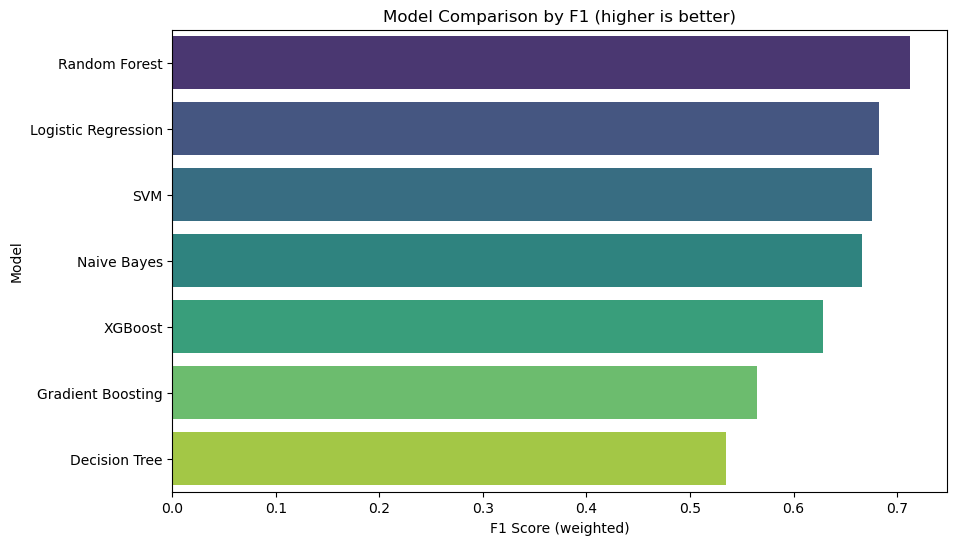

In [56]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_sorted, x="F1", y="Model", palette="viridis")
plt.title("Model Comparison by F1 (higher is better)")
plt.xlabel("F1 Score (weighted)")
plt.show()

### Best model selected based on the highest F1 score
---

## 17. Hyperparameter Tuning — Top Candidate
Tuning only the top performer, rather than every model, using `f1_weighted` as the scoring metric.

In [60]:
param_grid={
"classifier__n_estimators": [100, 200, 300],
"classifier__max_depth": [None, 20, 40]
}

pipeline = Pipeline(steps=[("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2)),
                        ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))])


print("Tuning: RandomForestClassifier")

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV F1 :", grid_search.best_score_)

Tuning: RandomForestClassifier
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Params: {'classifier__max_depth': None, 'classifier__n_estimators': 300}
Best CV F1 : 0.696511778485759


In [63]:
best_final_model = grid_search.best_estimator_
y_pred = best_final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Tuned {best_final_model
               } (Final Model)")
print(classification_report(y_test,y_pred))

Tuned Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=8000, min_df=2,
                                 ngram_range=(1, 2))),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))]) (Final Model)
              precision    recall  f1-score   support

    Negative       0.70      0.75      0.72      8476
     Neutral       0.69      0.64      0.66      8476
    Positive       0.75      0.75      0.75      8476

    accuracy                           0.71     25428
   macro avg       0.71      0.71      0.71     25428
weighted avg       0.71      0.71      0.71     25428



## 18. Save the Final Model

In [64]:
import pickle

with open("best_sentiment_model.pkl", "wb") as f:
    pickle.dump(best_final_model, f)

print("Model saved.")

Model saved.


In [69]:
results_sorted[["Model", "F1"]]

,Model,F1
0,Random Forest,0.713001
1,Logistic Regression,0.682587
2,SVM,0.675843
3,Naive Bayes,0.666626
4,XGBoost,0.628680
5,Gradient Boosting,0.565196
6,Decision Tree,0.535257


**Final model chosen**
- Baseline (Logistic Regression) F1: 0.682587
- Best model before tuning: Random Forest, F1: 0.713001
- Best model after tuning: Random Forest (tuned) — see printed F1 above from the GridSearchCV cell
- Improvement over baseline: +0.030414 F1 (Random Forest vs Logistic Regression), before tuning
- Why the improvement makes sense: Random Forest splits on individual TF-IDF word/bigram features, letting it pick up on word-combination and threshold effects in short review summaries that a single linear decision boundary (Logistic Regression) can't represent as flexibly.
